# Causal TCN Ensemble for Subject-Generalising FoG Detection

## Goal

Detect **whether FoG is occurring now** from lower-back accelerometer
signals and reconstruct complete episodes on people absent from model
training. This is a separate experiment; it does not replace the dense
or LSTM notebooks.

## Why this experiment

The earlier models use less than 0.1 seconds of temporal context. This
notebook instead uses a causal temporal convolutional network (TCN) with
approximately two seconds of past context, dense stride-one predictions,
validation-selected hysteresis, and true subject-level folds.

### Key assumptions

- `Time` is an integer sample index: DeFOG is 100 Hz and TDCS is 128 Hz.
- DeFOG uses `defog_metadata.csv`; TDCS uses `tdcsfog_metadata.csv`.
- Every recording belonging to one subject stays in one outer fold.
- Only training subjects fit scaling and class weights.
- One held-out development subgroup selects epochs; a disjoint subgroup
  selects the episode decoder.
- Outer test subjects are evaluated after those choices are frozen.
- Decoder state resets at recording and missing-time boundaries.

The notebook is intentionally generated without outputs. Run it from top
to bottom with the **Dissertation FoG (.venv)** kernel.

## 1. Setup

In [1]:
from pathlib import Path
import gc
import importlib
import sys

import numpy as np

print(f"Python executable: {sys.executable}")
print(f"NumPy version: {np.__version__}")
if int(np.__version__.split(".")[0]) >= 2:
    raise RuntimeError(
        "This notebook requires NumPy 1.26.x. Select the "
        "'Dissertation FoG (.venv)' kernel and restart the notebook."
    )

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from IPython import get_ipython
from IPython.display import display
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
)
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler

get_ipython().run_line_magic("matplotlib", "inline")
sns.set_theme(style="whitegrid", context="notebook")

PROJECT_ROOT = next(
    candidate
    for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / "src" / "fog_pipeline.py").exists()
)
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

importlib.invalidate_caches()
import fog_pipeline as _fog_pipeline
_fog_pipeline = importlib.reload(_fog_pipeline)

from fog_pipeline import (
    ANY_FOG_COLUMN,
    SEGMENT_COLUMN,
    SENSOR_COLUMNS,
    TARGET_COLUMNS,
    evaluate_episode_predictions,
    load_recordings,
)

Python executable: d:\Dissertation\.venv\Scripts\python.exe
NumPy version: 1.26.4


## 2. Configuration

In [ ]:
# Change only this value to run the other dataset.
DATASET_NAME = "tdcsfog"  # "tdcsfog" or "defog"

DATASET_CONFIG = {
    "defog": {
        "recordings_dir": PROJECT_ROOT / "data" / "raw" / "train" / "defog",
        "metadata_path": PROJECT_ROOT / "data" / "metadata" / "defog_metadata.csv",
        "sampling_rate_hz": 100.0,
        "filter_valid_task": True,
    },
    "tdcsfog": {
        "recordings_dir": PROJECT_ROOT / "data" / "raw" / "train" / "tdcsfog",
        "metadata_path": PROJECT_ROOT / "data" / "metadata" / "tdcsfog_metadata.csv",
        "sampling_rate_hz": 128.0,
        "filter_valid_task": False,
    },
}
if DATASET_NAME not in DATASET_CONFIG:
    raise ValueError(f"Unknown dataset: {DATASET_NAME}")
ACTIVE_CONFIG = DATASET_CONFIG[DATASET_NAME]
SAMPLING_RATE_HZ = ACTIVE_CONFIG["sampling_rate_hz"]

RANDOM_STATE = 42
N_OUTER_FOLDS = 5

# Start with the pilot. After it works, switch to "final" for the
# five-fold, three-seed dissertation experiment.
RUN_PROFILE = "final"  # "pilot" or "final"
if RUN_PROFILE == "pilot":
    FOLDS_TO_RUN = (0,)
    ENSEMBLE_SEEDS = (42,)
elif RUN_PROFILE == "final":
    FOLDS_TO_RUN = tuple(range(N_OUTER_FOLDS))
    ENSEMBLE_SEEDS = (42, 52, 62)
else:
    raise ValueError("RUN_PROFILE must be 'pilot' or 'final'")

CONTEXT_SECONDS = 2.0
OUTPUT_CHUNK_SECONDS = 8.0
TCN_FILTERS = 32
TCN_DILATIONS = (1, 2, 4, 8, 16, 32)
TCN_DROPOUT = 0.15
TCN_RECEPTIVE_FIELD_SAMPLES = 1 + 4 * sum(TCN_DILATIONS)
CONTEXT_SAMPLES = max(
    int(round(CONTEXT_SECONDS * SAMPLING_RATE_HZ)),
    TCN_RECEPTIVE_FIELD_SAMPLES - 1,
)
OUTPUT_CHUNK_SAMPLES = int(round(OUTPUT_CHUNK_SECONDS * SAMPLING_RATE_HZ))
AUXILIARY_TYPE_LOSS_WEIGHT = 0.2
CLASS_WEIGHT_POWER = 0.5
MAX_CLASS_WEIGHT = 20.0

BATCH_SIZE = 16
EPOCHS = 40
EARLY_STOPPING_PATIENCE = 20
LEARNING_RATE = 1e-3
SUBJECT_BALANCED_TRAINING = True
RUN_TRAINING = True

# The compact decoder grid tunes only the operating threshold.
# Confirmation timings remain fixed to reduce validation overfitting.
DECODER_ON_THRESHOLDS = np.arange(0.20, 0.91, 0.10)
DECODER_HYSTERESIS_GAP = 0.10
DECODER_ON_CONFIRM_SECONDS = 0.05
DECODER_OFF_CONFIRM_SECONDS = 0.10
EPISODE_IOU_THRESHOLD = 0.25

# Keep None: subject folds require the complete identity mapping.
MAX_RECORDINGS = None

print(
    {
        "dataset": DATASET_NAME,
        "run_profile": RUN_PROFILE,
        "sampling_rate_hz": SAMPLING_RATE_HZ,
        "context_samples": CONTEXT_SAMPLES,
        "actual_context_seconds": CONTEXT_SAMPLES / SAMPLING_RATE_HZ,
        "output_chunk_samples": OUTPUT_CHUNK_SAMPLES,
        "folds_to_run": FOLDS_TO_RUN,
        "ensemble_seeds": ENSEMBLE_SEEDS,
    }
)

{'dataset': 'tdcsfog', 'run_profile': 'final', 'sampling_rate_hz': 128.0, 'context_samples': 256, 'actual_context_seconds': 2.0, 'output_chunk_samples': 1024, 'folds_to_run': (0, 1, 2, 3, 4), 'ensemble_seeds': (42, 52, 62)}


## 3. Load identities and freeze subject folds

In [3]:
raw_data = load_recordings(
    recordings_dir=ACTIVE_CONFIG["recordings_dir"],
    metadata_path=ACTIVE_CONFIG["metadata_path"],
    limit_recordings=MAX_RECORDINGS,
    filter_valid_task=ACTIVE_CONFIG["filter_valid_task"],
)

# Fail loudly instead of allowing malformed time axes or sensor values
# to create silent segment breaks, NaN losses, or ambiguous alignment.
if raw_data[["RecordingId", "Subject"]].isna().any().any():
    raise ValueError("Recording and subject identities must be complete")
raw_data["Subject"] = raw_data["Subject"].astype(str).astype("category")
numeric_columns = ["Time", *SENSOR_COLUMNS, *TARGET_COLUMNS]
for numeric_column in numeric_columns:
    numeric_values = raw_data[numeric_column].to_numpy(dtype=np.float64)
    if not np.isfinite(numeric_values).all():
        raise ValueError(
            f"{numeric_column} must contain only finite values"
        )
del numeric_values
time_values = raw_data["Time"].to_numpy(dtype=np.float64)
if not np.equal(time_values, np.round(time_values)).all():
    raise ValueError("Time must contain integer sample indices")
if raw_data.duplicated(["RecordingId", "Time"]).any():
    raise ValueError("Each (RecordingId, Time) pair must be unique")
time_differences = raw_data.groupby(
    "RecordingId", sort=False, observed=True
)["Time"].diff()
if (time_differences.dropna() <= 0).any():
    raise ValueError("Time must be strictly increasing within recordings")

# Structural overview is safe to show before modelling; target EDA below
# is restricted to the development subjects of the first requested fold.
display(
    pd.Series(
        {
            "dataset": DATASET_NAME,
            "rows": len(raw_data),
            "recordings": raw_data["RecordingId"].nunique(),
            "subjects": raw_data["Subject"].nunique(),
            "sampling_rate_hz": SAMPLING_RATE_HZ,
        },
        name="dataset_structure",
    ).to_frame()
)

subject_manifest = (
    raw_data.assign(_AnyFoG=raw_data.loc[:, TARGET_COLUMNS].max(axis=1))
    .groupby("Subject", observed=True)
    .agg(
        rows=("Time", "size"),
        recordings=("RecordingId", "nunique"),
        any_fog_rows=("_AnyFoG", "sum"),
    )
    .reset_index()
)
subject_manifest["Subject"] = subject_manifest["Subject"].astype(str)
subject_manifest["any_fog_rate"] = (
    subject_manifest["any_fog_rows"] / subject_manifest["rows"]
)
if len(subject_manifest) < N_OUTER_FOLDS:
    raise ValueError(
        f"Need at least {N_OUTER_FOLDS} subjects for "
        f"{N_OUTER_FOLDS}-fold evaluation; found {len(subject_manifest)}"
    )

# Outcome burden is used only to balance deterministic folds. Every
# subject is still evaluated exactly once when all five folds are run.
stratum_count = min(
    N_OUTER_FOLDS,
    max(2, len(subject_manifest) // N_OUTER_FOLDS),
)
subject_manifest["stratum"] = pd.qcut(
    subject_manifest["any_fog_rate"].rank(method="first"),
    q=stratum_count,
    labels=False,
    duplicates="drop",
)

stratum_sizes = subject_manifest["stratum"].value_counts()
can_stratify = (
    len(stratum_sizes) > 1
    and int(stratum_sizes.min()) >= N_OUTER_FOLDS
)
splitter_class = StratifiedKFold if can_stratify else KFold
splitter = splitter_class(
    n_splits=N_OUTER_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)
subject_manifest["OuterFold"] = -1
split_target = subject_manifest["stratum"] if can_stratify else None
for fold, (_, test_indices) in enumerate(
    splitter.split(subject_manifest, split_target)
):
    subject_manifest.loc[test_indices, "OuterFold"] = fold

print(
    "Outer-fold assignment:",
    "burden-stratified" if can_stratify else "shuffled subject K-fold",
)

if (subject_manifest["OuterFold"] < 0).any():
    raise AssertionError("Every subject must receive one outer fold")

fold_by_subject = subject_manifest.set_index("Subject")["OuterFold"]
raw_data["OuterFold"] = (
    raw_data["Subject"].astype(str).map(fold_by_subject).astype(int)
)
if raw_data.groupby("Subject", observed=True)["OuterFold"].nunique().max() != 1:
    raise AssertionError("A subject appears in more than one outer fold")
if raw_data.groupby("RecordingId", observed=True)["OuterFold"].nunique().max() != 1:
    raise AssertionError("A recording appears in more than one outer fold")

fold_structure = raw_data.groupby("OuterFold", observed=True).agg(
    subjects=("Subject", "nunique"),
    recordings=("RecordingId", "nunique"),
    rows=("Time", "size"),
)
display(fold_structure)

,dataset_structure
dataset,tdcsfog
rows,7062672
recordings,833
subjects,62
sampling_rate_hz,128.0


Outer-fold assignment: burden-stratified


,subjects,recordings,rows
OuterFold,,,
0,13,168,1302745
1,13,194,1297132
2,12,168,2113365
3,12,151,1247251
4,12,152,1102179


## 4. Training-only EDA

,positive_rows,prevalence_percent
AnyFoG,1699441,38.080194
StartHesitation,286940,6.429603
Turn,1250974,28.031178
Walking,161527,3.619413


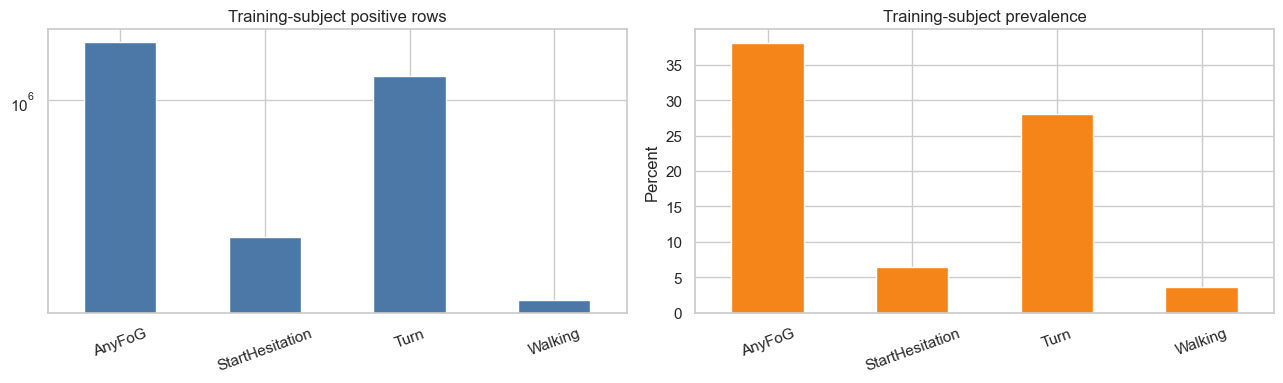

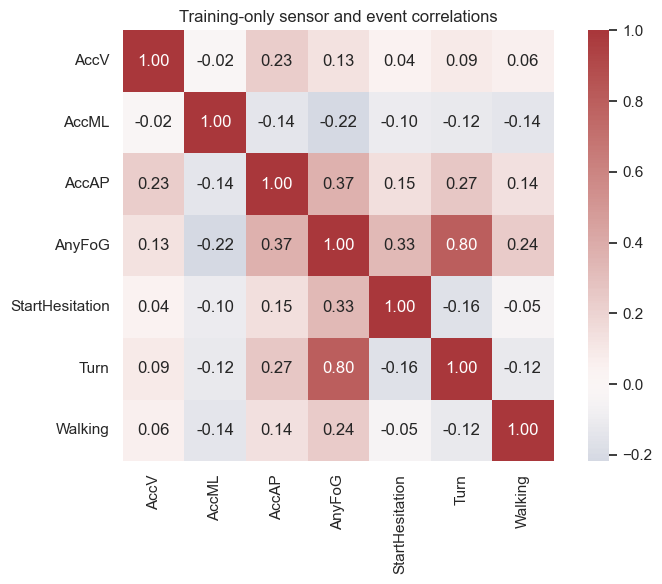

8184

In [4]:
eda_test_fold = int(FOLDS_TO_RUN[0])
eda_validation_fold = (eda_test_fold + 1) % N_OUTER_FOLDS
eda_training = raw_data.loc[
    ~raw_data["OuterFold"].isin([eda_test_fold, eda_validation_fold])
]

training_event_summary = pd.DataFrame(
    {
        "positive_rows": eda_training[
            [ANY_FOG_COLUMN, *TARGET_COLUMNS]
        ].sum(),
        "prevalence_percent": eda_training[
            [ANY_FOG_COLUMN, *TARGET_COLUMNS]
        ].mean()
        * 100,
    }
)
display(training_event_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
training_event_summary["positive_rows"].plot.bar(
    ax=axes[0], color="#4c78a8"
)
axes[0].set_yscale("log")
axes[0].set_title("Training-subject positive rows")
training_event_summary["prevalence_percent"].plot.bar(
    ax=axes[1], color="#f58518"
)
axes[1].set_title("Training-subject prevalence")
axes[1].set_ylabel("Percent")
for axis in axes:
    axis.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

eda_sample = eda_training.sample(
    n=min(200_000, len(eda_training)),
    random_state=RANDOM_STATE,
)
correlation_columns = [*SENSOR_COLUMNS, ANY_FOG_COLUMN, *TARGET_COLUMNS]
plt.figure(figsize=(8, 6))
sns.heatmap(
    eda_sample.loc[:, correlation_columns].corr(),
    cmap="vlag",
    center=0,
    annot=True,
    fmt=".2f",
    square=True,
)
plt.title("Training-only sensor and event correlations")
plt.tight_layout()
plt.show()

del eda_sample, eda_training
gc.collect()

## 5. Build causal, recording-bounded chunks

In [5]:
MODEL_FEATURES = (*SENSOR_COLUMNS, "AccMagnitude")


def add_contiguous_segments(frame):
    ordered = frame.sort_values(
        ["RecordingId", "Time"], kind="stable"
    ).copy()
    time_difference = ordered.groupby(
        "RecordingId", sort=False, observed=True
    )["Time"].diff()
    new_segment = time_difference.ne(1)
    ordered[SEGMENT_COLUMN] = (
        new_segment.groupby(
            ordered["RecordingId"], observed=True
        ).cumsum()
        - 1
    ).astype(np.int32)
    return ordered


def raw_feature_matrix(frame):
    sensor_values = frame.loc[:, SENSOR_COLUMNS].to_numpy(dtype=np.float32)
    magnitude = np.sqrt(np.square(sensor_values).sum(axis=1, keepdims=True))
    return np.concatenate([sensor_values, magnitude], axis=1)


def fit_training_scaler(training_frame):
    scaler = StandardScaler()
    for _, recording in training_frame.groupby(
        "RecordingId", sort=False, observed=True
    ):
        scaler.partial_fit(raw_feature_matrix(recording))
    return scaler


def build_segments(frame, scaler, *, include_alignment):
    segmented = add_contiguous_segments(frame)
    segments = []
    for (_, segment_number), segment in segmented.groupby(
        ["RecordingId", SEGMENT_COLUMN],
        sort=False,
        observed=True,
    ):
        segment = segment.sort_values("Time", kind="stable")
        features = scaler.transform(raw_feature_matrix(segment)).astype(
            np.float32
        )
        event_types = segment.loc[:, TARGET_COLUMNS].to_numpy(
            dtype=np.float32
        )
        any_fog = event_types.max(axis=1, keepdims=True).astype(np.float32)
        alignment = None
        if include_alignment:
            alignment = segment.loc[
                :, ["RecordingId", "Subject", "Time", SEGMENT_COLUMN]
            ].reset_index(drop=True)
        segments.append(
            {
                "x": features,
                "y_fog": any_fog,
                "y_type": event_types,
                "alignment": alignment,
                "subject": str(segment["Subject"].iloc[0]),
            }
        )
    return segments


def class_weights_from_segments(segments, subject_weights):
    # Estimate class balance under the same subject-balanced measure
    # used by the loss, so long recordings do not dominate either.
    row_count = 0.0
    fog_positive = 0.0
    type_positive = np.zeros(len(TARGET_COLUMNS), dtype=float)
    for segment in segments:
        subject_weight = float(
            subject_weights.get(segment["subject"], 1.0)
        )
        row_count += subject_weight * len(segment["y_fog"])
        fog_positive += subject_weight * float(segment["y_fog"].sum())
        type_positive += subject_weight * segment["y_type"].sum(axis=0)
    fog_negative = row_count - fog_positive
    type_negative = row_count - type_positive
    fog_weight = float(
        np.clip(
            (fog_negative / max(fog_positive, 1.0)) ** CLASS_WEIGHT_POWER,
            1.0,
            MAX_CLASS_WEIGHT,
        )
    )
    type_weights = np.clip(
        (type_negative / np.maximum(type_positive, 1.0))
        ** CLASS_WEIGHT_POWER,
        1.0,
        MAX_CLASS_WEIGHT,
    ).astype(np.float32)
    return fog_weight, type_weights


class CausalChunkSequence(tf.keras.utils.Sequence):
    def __init__(
        self,
        segments,
        *,
        context_samples,
        output_samples,
        batch_size,
        shuffle,
        seed,
        include_targets,
        subject_weights=None,
    ):
        super().__init__()
        self.segments = segments
        self.context_samples = int(context_samples)
        self.output_samples = int(output_samples)
        self.input_samples = self.context_samples + self.output_samples
        self.batch_size = int(batch_size)
        self.shuffle = bool(shuffle)
        self.include_targets = bool(include_targets)
        self.subject_weights = subject_weights or {}
        self.rng = np.random.default_rng(seed)
        self.references = [
            (segment_index, start)
            for segment_index, segment in enumerate(segments)
            for start in range(0, len(segment["x"]), self.output_samples)
        ]
        self.order = np.arange(len(self.references), dtype=np.int64)
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.references) / self.batch_size))

    def on_epoch_end(self):
        if self.shuffle:
            self.rng.shuffle(self.order)

    def __getitem__(self, batch_index):
        order_slice = self.order[
            batch_index * self.batch_size : (batch_index + 1)
            * self.batch_size
        ]
        current_batch_size = len(order_slice)
        x_batch = np.zeros(
            (
                current_batch_size,
                self.input_samples,
                len(MODEL_FEATURES),
            ),
            dtype=np.float32,
        )
        if self.include_targets:
            fog_batch = np.zeros(
                (current_batch_size, self.input_samples, 1),
                dtype=np.float32,
            )
            type_batch = np.zeros(
                (
                    current_batch_size,
                    self.input_samples,
                    len(TARGET_COLUMNS),
                ),
                dtype=np.float32,
            )
            weight_batch = np.zeros(
                (current_batch_size, self.input_samples), dtype=np.float32
            )

        for row, reference_index in enumerate(order_slice):
            segment_index, output_start = self.references[reference_index]
            segment = self.segments[segment_index]
            segment_length = len(segment["x"])
            source_start = max(0, output_start - self.context_samples)
            source_end = min(
                segment_length, output_start + self.output_samples
            )
            requested_start = output_start - self.context_samples
            destination_start = source_start - requested_start
            destination_end = destination_start + (source_end - source_start)

            x_batch[row, destination_start:destination_end] = segment["x"][
                source_start:source_end
            ]
            if self.include_targets:
                fog_batch[row, destination_start:destination_end] = segment[
                    "y_fog"
                ][source_start:source_end]
                type_batch[
                    row, destination_start:destination_end
                ] = segment["y_type"][source_start:source_end]

                output_end = min(
                    segment_length, output_start + self.output_samples
                )
                output_length = output_end - output_start
                subject_weight = float(
                    self.subject_weights.get(segment["subject"], 1.0)
                )
                weight_batch[
                    row,
                    self.context_samples : self.context_samples
                    + output_length,
                ] = subject_weight

        if not self.include_targets:
            return x_batch
        return (
            x_batch,
            {"fog": fog_batch, "event_type": type_batch},
            {"fog": weight_batch, "event_type": weight_batch},
        )


def make_subject_weights(training_frame):
    counts = training_frame.groupby("Subject", observed=True).size()
    if not SUBJECT_BALANCED_TRAINING:
        return {str(subject): 1.0 for subject in counts.index}
    total = float(counts.sum())
    subject_count = float(len(counts))
    return {
        str(subject): total / (subject_count * float(count))
        for subject, count in counts.items()
    }

## 6. Define the causal TCN

In [6]:
def make_weighted_binary_crossentropy(positive_weights):
    positive_weights = tf.constant(positive_weights, dtype=tf.float32)

    def weighted_binary_crossentropy(y_true, y_pred):
        y_pred = tf.clip_by_value(
            y_pred,
            tf.keras.backend.epsilon(),
            1.0 - tf.keras.backend.epsilon(),
        )
        element_loss = -(
            positive_weights * y_true * tf.math.log(y_pred)
            + (1.0 - y_true) * tf.math.log(1.0 - y_pred)
        )
        return tf.reduce_mean(element_loss, axis=-1)

    return weighted_binary_crossentropy


def build_causal_tcn(fog_positive_weight, type_positive_weights):
    inputs = tf.keras.layers.Input(
        shape=(None, len(MODEL_FEATURES)), name="accelerometer_sequence"
    )
    x = tf.keras.layers.Conv1D(TCN_FILTERS, kernel_size=1)(inputs)

    for dilation in TCN_DILATIONS:
        residual = x
        y = tf.keras.layers.LayerNormalization()(x)
        y = tf.keras.layers.Activation("swish")(y)
        y = tf.keras.layers.Conv1D(
            TCN_FILTERS,
            kernel_size=3,
            padding="causal",
            dilation_rate=dilation,
        )(y)
        y = tf.keras.layers.SpatialDropout1D(TCN_DROPOUT)(y)
        y = tf.keras.layers.LayerNormalization()(y)
        y = tf.keras.layers.Activation("swish")(y)
        y = tf.keras.layers.Conv1D(
            TCN_FILTERS,
            kernel_size=3,
            padding="causal",
            dilation_rate=dilation,
        )(y)
        x = tf.keras.layers.Add()([residual, y])

    shared = tf.keras.layers.LayerNormalization()(x)
    shared = tf.keras.layers.Activation("swish")(shared)
    fog_output = tf.keras.layers.Conv1D(
        1, kernel_size=1, activation="sigmoid", name="fog"
    )(shared)
    event_type_output = tf.keras.layers.Conv1D(
        len(TARGET_COLUMNS),
        kernel_size=1,
        activation="sigmoid",
        name="event_type",
    )(shared)

    model = tf.keras.Model(
        inputs=inputs,
        outputs={"fog": fog_output, "event_type": event_type_output},
    )
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss={
            "fog": make_weighted_binary_crossentropy(
                fog_positive_weight
            ),
            "event_type": make_weighted_binary_crossentropy(
                type_positive_weights
            ),
        },
        loss_weights={
            "fog": 1.0,
            "event_type": AUXILIARY_TYPE_LOSS_WEIGHT,
        },
        metrics={"fog": [], "event_type": []},
        weighted_metrics={
            "fog": [
                tf.keras.metrics.AUC(curve="PR", name="pr_auc"),
                tf.keras.metrics.Precision(name="precision"),
                tf.keras.metrics.Recall(name="recall"),
                tf.keras.metrics.BinaryAccuracy(
                    name="binary_accuracy"
                ),
            ],
            "event_type": [],
        },
    )
    return model


receptive_field_samples = TCN_RECEPTIVE_FIELD_SAMPLES
print(
    "Approximate TCN receptive field:",
    receptive_field_samples,
    "samples /",
    round(receptive_field_samples / SAMPLING_RATE_HZ, 3),
    "seconds",
)

Approximate TCN receptive field: 253 samples / 1.977 seconds


## 7. Prediction, hysteresis, and episode metrics

In [7]:
def predict_segment_scores(model, segments):
    sequence = CausalChunkSequence(
        segments,
        context_samples=CONTEXT_SAMPLES,
        output_samples=OUTPUT_CHUNK_SAMPLES,
        batch_size=BATCH_SIZE,
        shuffle=False,
        seed=RANDOM_STATE,
        include_targets=False,
    )
    # Score only the primary head; allocating auxiliary predictions for
    # every timestamp needlessly doubles inference memory.
    fog_model = tf.keras.Model(
        inputs=model.inputs,
        outputs=model.get_layer("fog").output,
    )
    fog_output = fog_model.predict(sequence, verbose=0)
    scores = [
        np.full(len(segment["x"]), np.nan, dtype=np.float32)
        for segment in segments
    ]
    for prediction_index, (segment_index, output_start) in enumerate(
        sequence.references
    ):
        output_end = min(
            len(segments[segment_index]["x"]),
            output_start + OUTPUT_CHUNK_SAMPLES,
        )
        output_length = output_end - output_start
        scores[segment_index][output_start:output_end] = fog_output[
            prediction_index,
            CONTEXT_SAMPLES : CONTEXT_SAMPLES + output_length,
            0,
        ]
    if any(np.isnan(score).any() for score in scores):
        raise AssertionError("Every evaluable timestamp needs one prediction")
    del fog_model, sequence, fog_output
    return scores


def hysteresis_decode(
    scores,
    *,
    on_threshold,
    off_threshold,
    on_confirm_samples,
    off_confirm_samples,
):
    predictions = np.zeros(len(scores), dtype=np.int8)
    state_on = False
    high_count = 0
    low_count = 0
    for index, score in enumerate(scores):
        if not state_on:
            high_count = high_count + 1 if score >= on_threshold else 0
            if high_count >= on_confirm_samples:
                state_on = True
                high_count = 0
                low_count = 0
        else:
            low_count = low_count + 1 if score < off_threshold else 0
            if low_count >= off_confirm_samples:
                state_on = False
                low_count = 0
                high_count = 0
        predictions[index] = int(state_on)
    return predictions


def decode_segment_scores(scores, on_threshold):
    off_threshold = max(
        0.01, on_threshold - DECODER_HYSTERESIS_GAP
    )
    on_samples = max(
        1,
        int(np.ceil(DECODER_ON_CONFIRM_SECONDS * SAMPLING_RATE_HZ)),
    )
    off_samples = max(
        1,
        int(np.ceil(DECODER_OFF_CONFIRM_SECONDS * SAMPLING_RATE_HZ)),
    )
    return [
        hysteresis_decode(
            segment_scores,
            on_threshold=on_threshold,
            off_threshold=off_threshold,
            on_confirm_samples=on_samples,
            off_confirm_samples=off_samples,
        )
        for segment_scores in scores
    ]


def flatten_segments(segments, scores, predictions=None):
    alignment = pd.concat(
        [segment["alignment"] for segment in segments],
        ignore_index=True,
    )
    truth = np.concatenate(
        [segment["y_fog"].reshape(-1) for segment in segments]
    ).astype(np.int8)
    score_vector = np.concatenate(scores).astype(np.float32)
    result = alignment.copy()
    result["AnyFoGTrue"] = truth
    result["AnyFoGScore"] = score_vector
    if predictions is not None:
        result["AnyFoGPredicted"] = np.concatenate(predictions).astype(
            np.int8
        )
    return result


def evaluate_decoded_frame(frame):
    return evaluate_episode_predictions(
        frame.loc[
            :, ["RecordingId", "Subject", "Time", SEGMENT_COLUMN]
        ],
        frame["AnyFoGTrue"].to_numpy(dtype=np.int8),
        frame["AnyFoGPredicted"].to_numpy(dtype=np.float32),
        threshold=0.5,
        sampling_rate_hz=SAMPLING_RATE_HZ,
        minimum_iou=EPISODE_IOU_THRESHOLD,
    )


def subject_macro_metrics(frame):
    rows = []
    for subject, subject_frame in frame.groupby(
        "Subject", sort=False, observed=True
    ):
        evaluation = evaluate_decoded_frame(subject_frame)
        rows.append(
            {
                "Subject": str(subject),
                "true_episodes": evaluation.true_count,
                "predicted_episodes": evaluation.predicted_count,
                "episode_precision": evaluation.precision,
                "episode_recall": evaluation.recall,
                "episode_f1": evaluation.f1,
                "false_alarms_per_minute": (
                    evaluation.false_alarms_per_minute
                ),
            }
        )
    subject_frame = pd.DataFrame(rows)
    macro = {}
    # Detection macros use the fixed population of subjects who have at
    # least one annotated episode. Undefined values (for example, no
    # predicted episodes) count as zero rather than changing the
    # denominator across candidate thresholds.
    positive_subject_mask = subject_frame["true_episodes"] > 0
    positive_subject_count = int(positive_subject_mask.sum())
    for source_name, output_name in (
        ("episode_precision", "macro_episode_precision"),
        ("episode_recall", "macro_episode_recall"),
        ("episode_f1", "macro_episode_f1"),
    ):
        values = subject_frame.loc[
            positive_subject_mask, source_name
        ].fillna(0.0)
        macro[output_name] = (
            values.mean() if positive_subject_count else np.nan
        )
        macro[f"{output_name}_n_subjects"] = positive_subject_count
    false_alarm_values = subject_frame["false_alarms_per_minute"]
    macro["macro_false_alarms_per_minute"] = false_alarm_values.mean(
        skipna=True
    )
    macro["macro_false_alarms_per_minute_n_subjects"] = int(
        false_alarm_values.notna().sum()
    )
    return subject_frame, macro


def select_validation_decoder(segments, scores):
    rows = []
    for on_threshold in DECODER_ON_THRESHOLDS:
        predictions = decode_segment_scores(scores, float(on_threshold))
        frame = flatten_segments(segments, scores, predictions)
        evaluation = evaluate_decoded_frame(frame)
        _, macro = subject_macro_metrics(frame)
        rows.append(
            {
                "on_threshold": float(on_threshold),
                "off_threshold": float(
                    max(0.01, on_threshold - DECODER_HYSTERESIS_GAP)
                ),
                "macro_episode_f1": macro["macro_episode_f1"],
                "macro_episode_f1_n_subjects": macro[
                    "macro_episode_f1_n_subjects"
                ],
                "macro_episode_recall": macro[
                    "macro_episode_recall"
                ],
                "macro_false_alarms_per_minute": macro[
                    "macro_false_alarms_per_minute"
                ],
                "episode_precision": evaluation.precision,
                "episode_recall": evaluation.recall,
                "episode_f1": evaluation.f1,
                "false_alarms_per_minute": (
                    evaluation.false_alarms_per_minute
                ),
            }
        )
    table = pd.DataFrame(rows)
    ranked = table.assign(
        _macro_f1=table["macro_episode_f1"].fillna(-np.inf),
        _macro_false_alarms=table[
            "macro_false_alarms_per_minute"
        ].fillna(
            np.inf
        ),
    ).sort_values(
        [
            "_macro_f1",
            "_macro_false_alarms",
            "macro_episode_recall",
        ],
        ascending=[False, True, False],
        kind="stable",
    )
    return float(ranked.iloc[0]["on_threshold"]), table

## 8. Train the requested fold ensemble(s)

In [8]:
histories = []
fold_results = []
outer_test_predictions = []

if RUN_TRAINING:
    for outer_fold in FOLDS_TO_RUN:
        outer_fold = int(outer_fold)
        validation_fold = (outer_fold + 1) % N_OUTER_FOLDS

        # Split the held-out development fold by subject. Early stopping
        # and decoder selection therefore do not reuse the same labels.
        ordered_development_subjects = (
            subject_manifest.loc[
                subject_manifest["OuterFold"] == validation_fold
            ]
            .sort_values(["any_fog_rate", "Subject"], kind="stable")
            ["Subject"]
            .tolist()
        )
        if len(ordered_development_subjects) < 2:
            raise ValueError(
                "Each development fold needs at least two subjects so "
                "early stopping and decoder calibration remain disjoint"
            )
        stopping_subjects = set(ordered_development_subjects[::2])
        calibration_subjects = set(ordered_development_subjects[1::2])
        train_subjects = set(
            subject_manifest.loc[
                ~subject_manifest["OuterFold"].isin(
                    [outer_fold, validation_fold]
                ),
                "Subject",
            ]
        )
        test_subjects = set(
            subject_manifest.loc[
                subject_manifest["OuterFold"] == outer_fold,
                "Subject",
            ]
        )
        subject_partitions = [
            train_subjects,
            stopping_subjects,
            calibration_subjects,
            test_subjects,
        ]
        for partition_index, left_partition in enumerate(
            subject_partitions
        ):
            for right_partition in subject_partitions[
                partition_index + 1 :
            ]:
                if left_partition & right_partition:
                    raise AssertionError("Fold subjects are not disjoint")

        training_frame = raw_data.loc[
            raw_data["Subject"].isin(train_subjects)
        ].copy()
        stopping_frame = raw_data.loc[
            raw_data["Subject"].isin(stopping_subjects)
        ].copy()
        calibration_frame = raw_data.loc[
            raw_data["Subject"].isin(calibration_subjects)
        ].copy()

        def contains_both_any_fog_classes(frame):
            positive_rows = int(frame[ANY_FOG_COLUMN].sum())
            return 0 < positive_rows < len(frame)


        for split_name, split_frame in (
            ("training", training_frame),
            ("early-stop", stopping_frame),
            ("decoder-calibration", calibration_frame),
        ):
            if not contains_both_any_fog_classes(split_frame):
                raise ValueError(
                    f"The {split_name} subjects in outer fold "
                    f"{outer_fold} do not contain both AnyFoG classes"
                )

        print(
            f"Outer fold {outer_fold}: "
            f"train={len(train_subjects)}, "
            f"early-stop={len(stopping_subjects)}, "
            f"decoder-calibration={len(calibration_subjects)}, "
            f"test={len(test_subjects)} subjects"
        )

        scaler = fit_training_scaler(training_frame)
        subject_weights = make_subject_weights(training_frame)
        training_segments = build_segments(
            training_frame, scaler, include_alignment=False
        )
        stopping_segments = build_segments(
            stopping_frame, scaler, include_alignment=False
        )
        calibration_segments = build_segments(
            calibration_frame, scaler, include_alignment=True
        )
        fog_positive_weight, type_positive_weights = (
            class_weights_from_segments(
                training_segments, subject_weights
            )
        )
        del training_frame, stopping_frame, calibration_frame
        gc.collect()
        print(
            "Class weights:",
            {
                "AnyFoG": round(fog_positive_weight, 3),
                **dict(
                    zip(
                        TARGET_COLUMNS,
                        np.round(type_positive_weights, 3),
                    )
                ),
            },
        )

        calibration_score_sum = [
            np.zeros(len(segment["x"]), dtype=np.float64)
            for segment in calibration_segments
        ]
        ensemble_weights = []

        for ensemble_seed in ENSEMBLE_SEEDS:
            tf.keras.backend.clear_session()
            tf.keras.utils.set_random_seed(int(ensemble_seed))
            training_sequence = CausalChunkSequence(
                training_segments,
                context_samples=CONTEXT_SAMPLES,
                output_samples=OUTPUT_CHUNK_SAMPLES,
                batch_size=BATCH_SIZE,
                shuffle=True,
                seed=int(ensemble_seed),
                include_targets=True,
                subject_weights=subject_weights,
            )
            stopping_sequence = CausalChunkSequence(
                stopping_segments,
                context_samples=CONTEXT_SAMPLES,
                output_samples=OUTPUT_CHUNK_SAMPLES,
                batch_size=BATCH_SIZE,
                shuffle=False,
                seed=RANDOM_STATE,
                include_targets=True,
            )
            model = build_causal_tcn(
                fog_positive_weight, type_positive_weights
            )
            history = model.fit(
                training_sequence,
                validation_data=stopping_sequence,
                epochs=EPOCHS,
                callbacks=[
                    tf.keras.callbacks.EarlyStopping(
                        monitor="val_fog_pr_auc",
                        mode="max",
                        min_delta=1e-4,
                        patience=EARLY_STOPPING_PATIENCE,
                        restore_best_weights=True,
                    ),
                    tf.keras.callbacks.ReduceLROnPlateau(
                        monitor="val_fog_pr_auc",
                        mode="max",
                        factor=0.5,
                        patience=max(
                            2, EARLY_STOPPING_PATIENCE // 2
                        ),
                        min_lr=1e-5,
                    ),
                ],
                verbose=2,
            )
            history_frame = pd.DataFrame(history.history)
            history_frame["outer_fold"] = outer_fold
            history_frame["seed"] = int(ensemble_seed)
            history_frame["epoch"] = np.arange(len(history_frame))
            histories.append(history_frame)

            seed_calibration_scores = predict_segment_scores(
                model, calibration_segments
            )
            for accumulator, values in zip(
                calibration_score_sum, seed_calibration_scores
            ):
                accumulator += values
            ensemble_weights.append(model.get_weights())

            del (
                model,
                training_sequence,
                stopping_sequence,
                seed_calibration_scores,
            )
            gc.collect()

        calibration_scores = [
            (values / len(ENSEMBLE_SEEDS)).astype(np.float32)
            for values in calibration_score_sum
        ]

        selected_threshold, decoder_table = select_validation_decoder(
            calibration_segments, calibration_scores
        )
        print(
            f"Outer fold {outer_fold} calibration-selected "
            f"decoder threshold: {selected_threshold:.2f}"
        )
        display(decoder_table)

        # Only now, after model weights and the decoder are frozen, is
        # the untouched outer-test fold transformed and scored.
        test_frame = raw_data.loc[
            raw_data["Subject"].isin(test_subjects)
        ].copy()
        test_segments = build_segments(
            test_frame, scaler, include_alignment=True
        )
        del test_frame
        test_score_sum = [
            np.zeros(len(segment["x"]), dtype=np.float64)
            for segment in test_segments
        ]
        for seed_weights in ensemble_weights:
            tf.keras.backend.clear_session()
            inference_model = build_causal_tcn(
                fog_positive_weight, type_positive_weights
            )
            inference_model.set_weights(seed_weights)
            seed_test_scores = predict_segment_scores(
                inference_model, test_segments
            )
            for accumulator, values in zip(
                test_score_sum, seed_test_scores
            ):
                accumulator += values
            del inference_model, seed_test_scores
            gc.collect()
        test_scores = [
            (values / len(ENSEMBLE_SEEDS)).astype(np.float32)
            for values in test_score_sum
        ]

        test_predictions = decode_segment_scores(
            test_scores, selected_threshold
        )
        test_output = flatten_segments(
            test_segments, test_scores, test_predictions
        )
        test_output["OuterFold"] = outer_fold
        outer_test_predictions.append(test_output)

        episode_evaluation = evaluate_decoded_frame(test_output)
        _, macro_metrics = subject_macro_metrics(test_output)
        fold_results.append(
            {
                "outer_fold": outer_fold,
                "test_subjects": len(test_subjects),
                "selected_on_threshold": selected_threshold,
                "average_precision": average_precision_score(
                    test_output["AnyFoGTrue"],
                    test_output["AnyFoGScore"],
                ),
                "true_episodes": episode_evaluation.true_count,
                "predicted_episodes": (
                    episode_evaluation.predicted_count
                ),
                "matched_episodes": (
                    episode_evaluation.true_positive_count
                ),
                "episode_precision": episode_evaluation.precision,
                "episode_recall": episode_evaluation.recall,
                "episode_f1": episode_evaluation.f1,
                "false_alarms_per_minute": (
                    episode_evaluation.false_alarms_per_minute
                ),
                "median_onset_delay_seconds": (
                    episode_evaluation.median_onset_delay_seconds
                ),
                "mean_absolute_onset_error_seconds": (
                    episode_evaluation.mean_absolute_onset_error_seconds
                ),
                "mean_matched_iou": (
                    episode_evaluation.mean_duration_iou
                ),
                **macro_metrics,
            }
        )

        del (
            training_segments,
            stopping_segments,
            calibration_segments,
            test_segments,
            calibration_score_sum,
            test_score_sum,
            ensemble_weights,
            calibration_scores,
            test_scores,
            scaler,
            subject_weights,
        )
        tf.keras.backend.clear_session()
        gc.collect()
else:
    print("Training is disabled. Set RUN_TRAINING=True when ready.")

Outer fold 0: train=36, early-stop=7, decoder-calibration=6, test=13 subjects
Class weights: {'AnyFoG': 2.098, 'StartHesitation': 7.549, 'Turn': 2.308, 'Walking': 10.045}

Epoch 1/40
288/288 - 46s - 161ms/step - event_type_loss: 0.3557 - fog_binary_accuracy: 0.7859 - fog_loss: 0.4621 - fog_pr_auc: 0.4511 - fog_precision: 0.4323 - fog_recall: 0.4997 - loss: 0.5300 - val_event_type_loss: 0.2840 - val_fog_binary_accuracy: 0.8305 - val_fog_loss: 0.4142 - val_fog_pr_auc: 0.4459 - val_fog_precision: 0.5294 - val_fog_recall: 0.4635 - val_loss: 0.4723 - learning_rate: 0.0010
Epoch 2/40
288/288 - 31s - 109ms/step - event_type_loss: 0.2886 - fog_binary_accuracy: 0.8227 - fog_loss: 0.3893 - fog_pr_auc: 0.5776 - fog_precision: 0.5166 - fog_recall: 0.6584 - loss: 0.4478 - val_event_type_loss: 0.2812 - val_fog_binary_accuracy: 0.7338 - val_fog_loss: 0.4275 - val_fog_pr_auc: 0.4404 - val_fog_precision: 0.3695 - val_fog_recall: 0.6935 - val_loss: 0.4843 - learning_rate: 0.0010
Epoch 3/40
288/288 - 36s

,on_threshold,off_threshold,macro_episode_f1,macro_episode_f1_n_subjects,macro_episode_recall,macro_false_alarms_per_minute,episode_precision,episode_recall,episode_f1,false_alarms_per_minute
0,0.2,0.1,0.247246,4,0.513464,4.365452,0.123967,0.401786,0.189474,4.169502
1,0.3,0.2,0.298380,4,0.539155,4.731766,0.137306,0.473214,0.212851,4.366177
2,0.4,0.3,0.323614,4,0.549904,4.218755,0.168605,0.517857,0.254386,3.749930
3,0.5,0.4,0.317426,4,0.509214,3.584158,0.180328,0.491071,0.263789,3.277910
4,0.6,0.5,0.319606,4,0.468344,2.631504,0.210762,0.419643,0.280597,2.307649
5,0.7,0.6,0.273083,4,0.353849,1.859756,0.224359,0.312500,0.261194,1.586509
6,0.8,0.7,0.198555,4,0.286178,1.357469,0.208696,0.214286,0.211454,1.193159
7,0.9,0.8,0.151462,4,0.171836,0.556956,0.224138,0.116071,0.152941,0.590024


Outer fold 1: train=37, early-stop=6, decoder-calibration=6, test=13 subjects
Class weights: {'AnyFoG': 2.096, 'StartHesitation': 9.773, 'Turn': 2.248, 'Walking': 9.997}
Epoch 1/40
238/238 - 38s - 159ms/step - event_type_loss: 0.3451 - fog_binary_accuracy: 0.8013 - fog_loss: 0.4517 - fog_pr_auc: 0.4854 - fog_precision: 0.4663 - fog_recall: 0.4955 - loss: 0.5208 - val_event_type_loss: 0.2988 - val_fog_binary_accuracy: 0.8117 - val_fog_loss: 0.3947 - val_fog_pr_auc: 0.4435 - val_fog_precision: 0.3912 - val_fog_recall: 0.4324 - val_loss: 0.4572 - learning_rate: 0.0010
Epoch 2/40
238/238 - 28s - 116ms/step - event_type_loss: 0.2689 - fog_binary_accuracy: 0.8421 - fog_loss: 0.3652 - fog_pr_auc: 0.6427 - fog_precision: 0.5619 - fog_recall: 0.6732 - loss: 0.4189 - val_event_type_loss: 0.2972 - val_fog_binary_accuracy: 0.8205 - val_fog_loss: 0.4331 - val_fog_pr_auc: 0.3687 - val_fog_precision: 0.4037 - val_fog_recall: 0.3815 - val_loss: 0.4959 - learning_rate: 0.0010
Epoch 3/40
238/238 - 26s -

,on_threshold,off_threshold,macro_episode_f1,macro_episode_f1_n_subjects,macro_episode_recall,macro_false_alarms_per_minute,episode_precision,episode_recall,episode_f1,false_alarms_per_minute
0,0.2,0.1,0.220139,4,0.304545,3.725712,0.190299,0.392308,0.256281,1.168256
1,0.3,0.2,0.137530,4,0.380927,4.215183,0.083994,0.407692,0.139290,3.111759
2,0.4,0.3,0.168394,4,0.390096,3.999962,0.081752,0.430769,0.137423,3.386326
3,0.5,0.4,0.155848,4,0.359492,4.195906,0.072702,0.407692,0.123399,3.639359
4,0.6,0.5,0.139336,4,0.269691,3.269447,0.055249,0.307692,0.093677,3.682428
5,0.7,0.6,0.080614,4,0.145337,2.766290,0.042017,0.192308,0.068966,3.068690
6,0.8,0.7,0.043779,4,0.047123,0.813862,0.036036,0.061538,0.045455,1.152105
7,0.9,0.8,0.000000,4,0.000000,0.004863,0.000000,0.000000,0.000000,0.021535


Outer fold 2: train=38, early-stop=6, decoder-calibration=6, test=12 subjects
Class weights: {'AnyFoG': 2.309, 'StartHesitation': 14.837, 'Turn': 2.444, 'Walking': 9.912}
Epoch 1/40
242/242 - 36s - 150ms/step - event_type_loss: 0.3276 - fog_binary_accuracy: 0.8159 - fog_loss: 0.4523 - fog_pr_auc: 0.4023 - fog_precision: 0.4143 - fog_recall: 0.3999 - loss: 0.5179 - val_event_type_loss: 0.2639 - val_fog_binary_accuracy: 0.8372 - val_fog_loss: 0.5903 - val_fog_pr_auc: 0.3691 - val_fog_precision: 0.4918 - val_fog_recall: 0.2430 - val_loss: 0.6423 - learning_rate: 0.0010
Epoch 2/40
242/242 - 27s - 112ms/step - event_type_loss: 0.2622 - fog_binary_accuracy: 0.8413 - fog_loss: 0.3871 - fog_pr_auc: 0.5340 - fog_precision: 0.4980 - fog_recall: 0.5812 - loss: 0.4394 - val_event_type_loss: 0.2093 - val_fog_binary_accuracy: 0.8625 - val_fog_loss: 0.4019 - val_fog_pr_auc: 0.5551 - val_fog_precision: 0.5834 - val_fog_recall: 0.5212 - val_loss: 0.4428 - learning_rate: 0.0010
Epoch 3/40
242/242 - 27s 

,on_threshold,off_threshold,macro_episode_f1,macro_episode_f1_n_subjects,macro_episode_recall,macro_false_alarms_per_minute,episode_precision,episode_recall,episode_f1,false_alarms_per_minute
0,0.2,0.1,0.296614,4,0.621726,3.617553,0.164179,0.698413,0.265861,3.079622
1,0.3,0.2,0.235534,4,0.533631,4.104338,0.148026,0.714286,0.245232,3.560813
2,0.4,0.3,0.245257,4,0.581548,4.060412,0.160410,0.746032,0.264045,3.382085
3,0.5,0.4,0.216256,4,0.527083,3.478441,0.164751,0.682540,0.265432,2.997132
4,0.6,0.5,0.194048,4,0.452083,2.742746,0.160870,0.587302,0.252560,2.653424
5,0.7,0.6,0.170329,4,0.345833,2.146235,0.143564,0.460317,0.218868,2.378458
6,0.8,0.7,0.152287,4,0.270833,1.393297,0.129032,0.317460,0.183486,1.856022
7,0.9,0.8,0.093478,4,0.108333,0.294660,0.240000,0.095238,0.136364,0.261218


Outer fold 3: train=38, early-stop=6, decoder-calibration=6, test=12 subjects
Class weights: {'AnyFoG': 2.327, 'StartHesitation': 9.344, 'Turn': 2.56, 'Walking': 8.992}
Epoch 1/40
305/305 - 52s - 171ms/step - event_type_loss: 0.3366 - fog_binary_accuracy: 0.8006 - fog_loss: 0.4530 - fog_pr_auc: 0.3769 - fog_precision: 0.3789 - fog_recall: 0.4365 - loss: 0.5208 - val_event_type_loss: 0.2687 - val_fog_binary_accuracy: 0.8132 - val_fog_loss: 0.5096 - val_fog_pr_auc: 0.3397 - val_fog_precision: 0.3988 - val_fog_recall: 0.2670 - val_loss: 0.5634 - learning_rate: 0.0010
Epoch 2/40
305/305 - 41s - 134ms/step - event_type_loss: 0.2764 - fog_binary_accuracy: 0.8311 - fog_loss: 0.3851 - fog_pr_auc: 0.5415 - fog_precision: 0.4681 - fog_recall: 0.6133 - loss: 0.4407 - val_event_type_loss: 0.2520 - val_fog_binary_accuracy: 0.7577 - val_fog_loss: 0.4348 - val_fog_pr_auc: 0.4363 - val_fog_precision: 0.3709 - val_fog_recall: 0.6798 - val_loss: 0.4852 - learning_rate: 0.0010
Epoch 3/40
305/305 - 41s - 

,on_threshold,off_threshold,macro_episode_f1,macro_episode_f1_n_subjects,macro_episode_recall,macro_false_alarms_per_minute,episode_precision,episode_recall,episode_f1,false_alarms_per_minute
0,0.2,0.1,0.427991,4,0.566922,2.212549,0.281588,0.458824,0.348993,2.718255
1,0.3,0.2,0.378842,4,0.517207,2.543302,0.261168,0.447059,0.329718,2.936808
2,0.4,0.3,0.389230,4,0.512287,2.060440,0.291971,0.470588,0.360360,2.649957
3,0.5,0.4,0.286830,4,0.379344,1.868591,0.252066,0.358824,0.296117,2.472383
4,0.6,0.5,0.301924,4,0.366395,1.511231,0.296482,0.347059,0.319783,1.912340
5,0.7,0.6,0.259671,4,0.286435,1.279889,0.273973,0.235294,0.253165,1.447915
6,0.8,0.7,0.208152,4,0.205952,0.969515,0.264706,0.158824,0.198529,1.024468
7,0.9,0.8,0.134068,4,0.110406,0.741796,0.196721,0.070588,0.103896,0.669319


Outer fold 4: train=37, early-stop=7, decoder-calibration=6, test=12 subjects
Class weights: {'AnyFoG': 2.217, 'StartHesitation': 7.772, 'Turn': 2.463, 'Walking': 9.401}
Epoch 1/40
301/301 - 77s - 256ms/step - event_type_loss: 0.3512 - fog_binary_accuracy: 0.8123 - fog_loss: 0.4533 - fog_pr_auc: 0.4473 - fog_precision: 0.4483 - fog_recall: 0.4775 - loss: 0.5242 - val_event_type_loss: 0.5293 - val_fog_binary_accuracy: 0.6888 - val_fog_loss: 0.6625 - val_fog_pr_auc: 0.4543 - val_fog_precision: 0.3961 - val_fog_recall: 0.2253 - val_loss: 0.7727 - learning_rate: 0.0010
Epoch 2/40
301/301 - 61s - 204ms/step - event_type_loss: 0.2827 - fog_binary_accuracy: 0.8448 - fog_loss: 0.3702 - fog_pr_auc: 0.6067 - fog_precision: 0.5334 - fog_recall: 0.6528 - loss: 0.4275 - val_event_type_loss: 0.4795 - val_fog_binary_accuracy: 0.7912 - val_fog_loss: 0.5408 - val_fog_pr_auc: 0.5993 - val_fog_precision: 0.6743 - val_fog_recall: 0.4834 - val_loss: 0.6410 - learning_rate: 0.0010
Epoch 3/40
301/301 - 61s -

,on_threshold,off_threshold,macro_episode_f1,macro_episode_f1_n_subjects,macro_episode_recall,macro_false_alarms_per_minute,episode_precision,episode_recall,episode_f1,false_alarms_per_minute
0,0.2,0.1,0.248638,4,0.326889,3.765350,0.139159,0.425743,0.209756,3.659803
1,0.3,0.2,0.294641,4,0.435779,4.583895,0.142487,0.544554,0.225873,4.554116
2,0.4,0.3,0.268630,4,0.403374,4.787137,0.124694,0.504950,0.200000,4.925599
3,0.5,0.4,0.297537,4,0.465047,4.190545,0.144068,0.504950,0.224176,4.168873
4,0.6,0.5,0.327560,4,0.446441,3.316023,0.188889,0.504950,0.274933,3.013146
5,0.7,0.6,0.273389,4,0.350388,2.640547,0.191388,0.396040,0.258065,2.325213
6,0.8,0.7,0.248892,4,0.279993,1.509878,0.253968,0.316832,0.281938,1.293314
7,0.9,0.8,0.145349,4,0.160256,0.489668,0.396825,0.247525,0.304878,0.522829


## 9. Learning curves

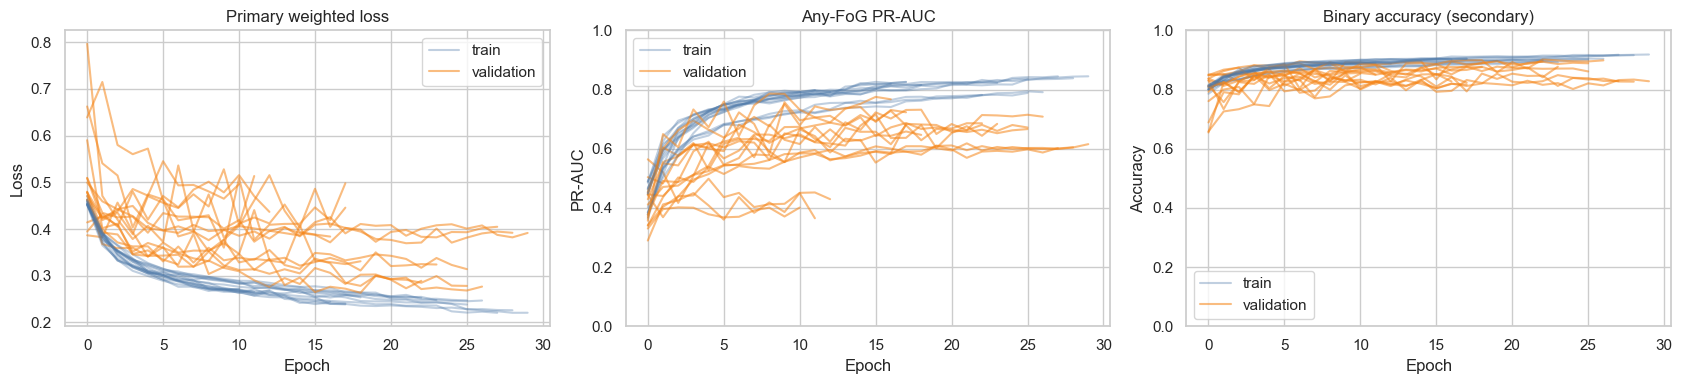

In [9]:
if histories:
    history_results = pd.concat(histories, ignore_index=True)
    fig, axes = plt.subplots(1, 3, figsize=(17, 4))
    curve_specs = [
        ("fog_loss", "val_fog_loss", "Primary weighted loss", "Loss"),
        ("fog_pr_auc", "val_fog_pr_auc", "Any-FoG PR-AUC", "PR-AUC"),
        (
            "fog_binary_accuracy",
            "val_fog_binary_accuracy",
            "Binary accuracy (secondary)",
            "Accuracy",
        ),
    ]
    for run_index, ((fold, seed), run) in enumerate(
        history_results.groupby(["outer_fold", "seed"], sort=True)
    ):
        for axis, (train_key, validation_key, title, ylabel) in zip(
            axes, curve_specs
        ):
            if train_key not in run or validation_key not in run:
                continue
            axis.plot(
                run["epoch"],
                run[train_key],
                color="#4c78a8",
                alpha=0.35,
                label="train" if run_index == 0 else None,
            )
            axis.plot(
                run["epoch"],
                run[validation_key],
                color="#f58518",
                alpha=0.55,
                label="validation" if run_index == 0 else None,
            )
            axis.set_title(title)
            axis.set_xlabel("Epoch")
            axis.set_ylabel(ylabel)
    for axis in axes:
        axis.legend()
    axes[1].set_ylim(0, 1)
    axes[2].set_ylim(0, 1)
    plt.tight_layout()
    plt.show()
else:
    print("Learning curves appear after training.")

## 10. Outer-fold episode results

,test_subjects,selected_on_threshold,average_precision,true_episodes,predicted_episodes,matched_episodes,episode_precision,episode_recall,episode_f1,false_alarms_per_minute,...,mean_absolute_onset_error_seconds,mean_matched_iou,macro_episode_precision,macro_episode_precision_n_subjects,macro_episode_recall,macro_episode_recall_n_subjects,macro_episode_f1,macro_episode_f1_n_subjects,macro_false_alarms_per_minute,macro_false_alarms_per_minute_n_subjects
outer_fold,,,,,,,,,,,,,,,,,,,,,
0,13,0.4,0.790873,196,752,119,0.158245,0.607143,0.251055,3.731690,...,1.838957,0.631186,0.259381,9,0.561307,9,0.314046,9,3.732562,13
1,13,0.2,0.492890,231,886,91,0.102709,0.393939,0.162936,4.707000,...,3.169643,0.528468,0.157180,8,0.461565,8,0.227144,8,4.951037,13
2,12,0.2,0.957254,236,746,112,0.150134,0.474576,0.228106,2.303965,...,11.902762,0.569622,0.160189,8,0.417579,8,0.216700,8,4.025954,12
3,12,0.2,0.783433,141,574,93,0.162021,0.659574,0.260140,2.961778,...,4.505376,0.586396,0.271456,8,0.635890,8,0.360841,8,3.163985,12
4,12,0.6,0.588464,328,538,141,0.262082,0.429878,0.325635,2.766302,...,2.314993,0.515793,0.332518,8,0.454811,8,0.364782,8,2.594692,12


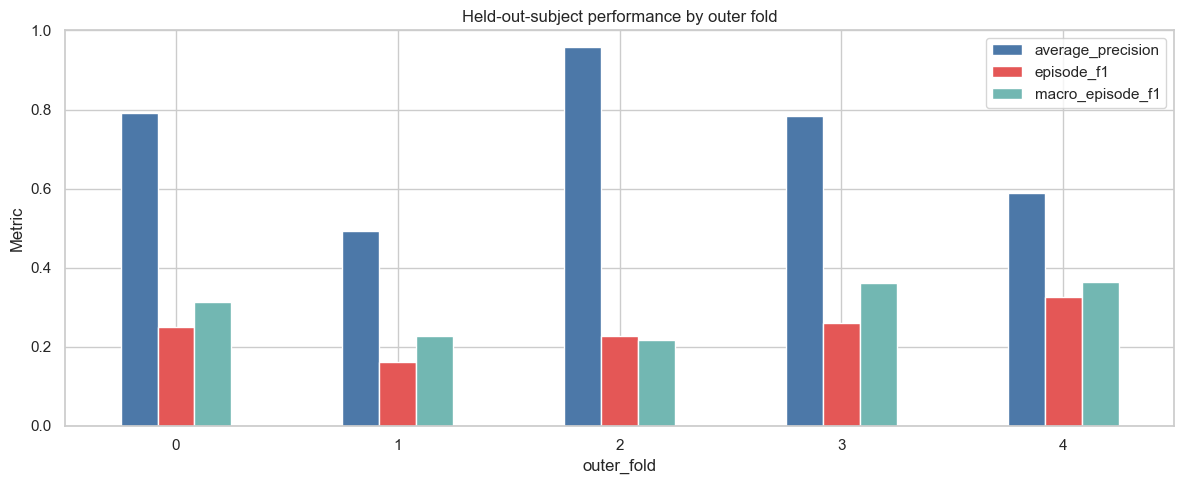

,outer_fold_summary
evaluated_outer_folds,5.000000
evaluated_subjects,62.000000
mean_fold_average_precision,0.722583
std_fold_average_precision,0.183156
true_episodes,1132.000000
predicted_episodes,3496.000000
matched_episodes,556.000000
episode_precision,0.159039
episode_recall,0.491166
episode_f1,0.240277


,count,mean,std,min,25%,50%,75%,max
true_episodes,62.0,18.258065,19.414322,0.000000,0.000000,13.000000,27.000000,78.000000
predicted_episodes,62.0,56.387097,39.117459,0.000000,31.500000,47.500000,80.500000,174.000000
episode_precision,61.0,0.159101,0.191502,0.000000,0.000000,0.097561,0.228571,0.705882
episode_recall,41.0,0.507574,0.214654,0.086957,0.333333,0.545455,0.652174,1.000000
episode_f1,61.0,0.199707,0.211727,0.000000,0.000000,0.154762,0.294118,0.769231
false_alarms_per_minute,62.0,3.714554,2.032650,0.000000,2.093815,3.793624,5.268117,8.251015


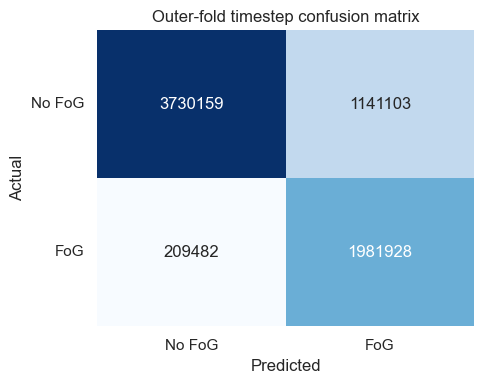

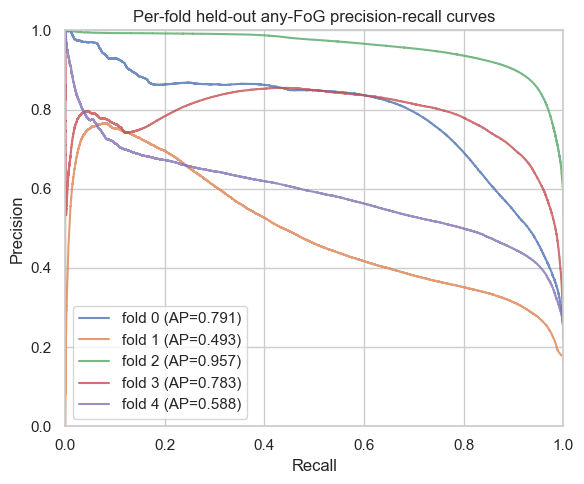

In [10]:
if fold_results:
    fold_results_frame = pd.DataFrame(fold_results).set_index(
        "outer_fold"
    )
    display(fold_results_frame)

    plot_columns = [
        "average_precision",
        "episode_f1",
        "macro_episode_f1",
    ]
    axes = fold_results_frame[plot_columns].plot.bar(
        figsize=(12, 5),
        color=["#4c78a8", "#e45756", "#72b7b2"],
    )
    axes.set_title("Held-out-subject performance by outer fold")
    axes.set_ylabel("Metric")
    axes.set_ylim(0, 1)
    axes.tick_params(axis="x", rotation=0)
    plt.tight_layout()
    plt.show()

    all_outer_predictions = pd.concat(
        outer_test_predictions, ignore_index=True
    )
    overall_episode_evaluation = evaluate_decoded_frame(
        all_outer_predictions
    )
    subject_results, overall_macro = subject_macro_metrics(
        all_outer_predictions
    )
    overall_summary = pd.Series(
        {
            "evaluated_outer_folds": len(fold_results_frame),
            "evaluated_subjects": all_outer_predictions[
                "Subject"
            ].nunique(),
            # Fold score scales need not be calibrated to one another,
            # so report the distribution of fold AP rather than a pooled
            # AP computed from incomparable raw probabilities.
            "mean_fold_average_precision": fold_results_frame[
                "average_precision"
            ].mean(),
            "std_fold_average_precision": fold_results_frame[
                "average_precision"
            ].std(ddof=1),
            "true_episodes": overall_episode_evaluation.true_count,
            "predicted_episodes": (
                overall_episode_evaluation.predicted_count
            ),
            "matched_episodes": (
                overall_episode_evaluation.true_positive_count
            ),
            "episode_precision": overall_episode_evaluation.precision,
            "episode_recall": overall_episode_evaluation.recall,
            "episode_f1": overall_episode_evaluation.f1,
            "false_alarms_per_minute": (
                overall_episode_evaluation.false_alarms_per_minute
            ),
            "median_onset_delay_seconds": (
                overall_episode_evaluation.median_onset_delay_seconds
            ),
            "mean_absolute_onset_error_seconds": (
                overall_episode_evaluation.mean_absolute_onset_error_seconds
            ),
            "mean_iou_among_matches": (
                overall_episode_evaluation.mean_duration_iou
            ),
            **overall_macro,
        },
        name="outer_fold_summary",
    )
    display(overall_summary.to_frame())
    display(subject_results.describe().T)

    matrix = confusion_matrix(
        all_outer_predictions["AnyFoGTrue"],
        all_outer_predictions["AnyFoGPredicted"],
        labels=[0, 1],
    )
    plt.figure(figsize=(5, 4))
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title("Outer-fold timestep confusion matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks([0.5, 1.5], ["No FoG", "FoG"])
    plt.yticks([0.5, 1.5], ["No FoG", "FoG"], rotation=0)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 5))
    for outer_fold, fold_predictions in all_outer_predictions.groupby(
        "OuterFold", sort=True, observed=True
    ):
        precision, recall, _ = precision_recall_curve(
            fold_predictions["AnyFoGTrue"],
            fold_predictions["AnyFoGScore"],
        )
        fold_ap = average_precision_score(
            fold_predictions["AnyFoGTrue"],
            fold_predictions["AnyFoGScore"],
        )
        plt.plot(
            recall,
            precision,
            alpha=0.8,
            label=f"fold {outer_fold} (AP={fold_ap:.3f})",
        )
    plt.title("Per-fold held-out any-FoG precision-recall curves")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Outer-fold results appear after training.")

## 11. Held-out timing example

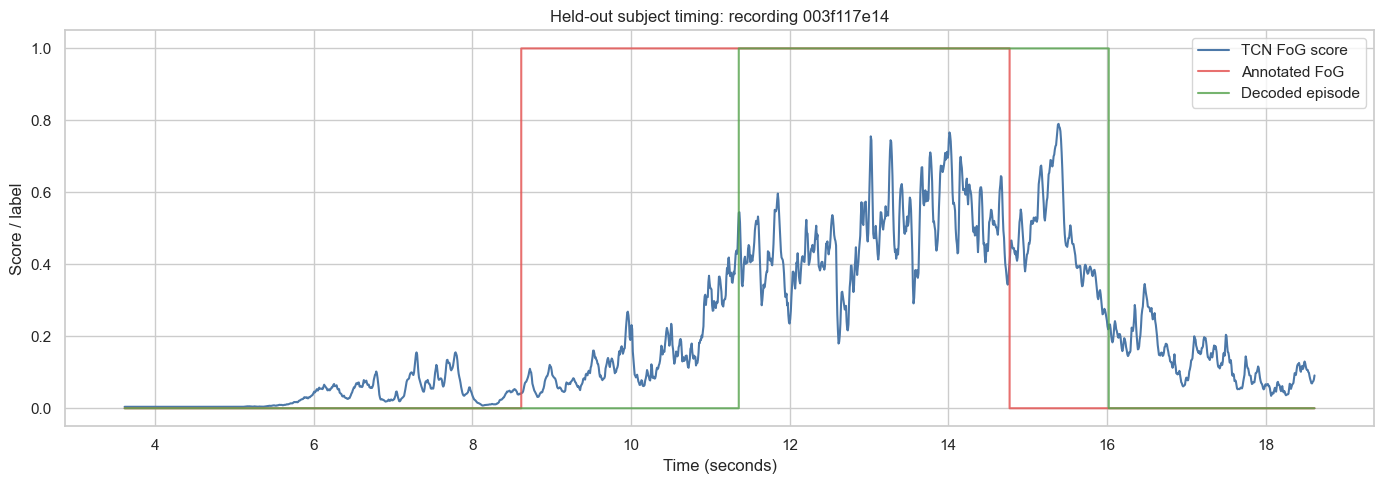

In [11]:
if outer_test_predictions:
    positive_totals = all_outer_predictions.groupby(
        "RecordingId", observed=True
    )["AnyFoGTrue"].sum()
    positive_recordings = sorted(
        positive_totals.loc[positive_totals > 0].index,
        key=str,
    )
    if positive_recordings:
        recording_id = positive_recordings[0]
        example = all_outer_predictions.loc[
            all_outer_predictions["RecordingId"] == recording_id
        ].sort_values("Time", kind="stable")
        example = example.assign(
            TimeSeconds=example["Time"] / SAMPLING_RATE_HZ
        )
        first_event_time = float(
            example.loc[
                example["AnyFoGTrue"] == 1, "TimeSeconds"
            ].iloc[0]
        )
        window = example.loc[
            example["TimeSeconds"].between(
                max(0.0, first_event_time - 5.0),
                first_event_time + 10.0,
            )
        ]
        fig, axis = plt.subplots(figsize=(14, 5))
        axis.plot(
            window["TimeSeconds"],
            window["AnyFoGScore"],
            color="#4c78a8",
            label="TCN FoG score",
        )
        axis.step(
            window["TimeSeconds"],
            window["AnyFoGTrue"],
            where="post",
            color="#e45756",
            alpha=0.85,
            label="Annotated FoG",
        )
        axis.step(
            window["TimeSeconds"],
            window["AnyFoGPredicted"],
            where="post",
            color="#54a24b",
            alpha=0.8,
            label="Decoded episode",
        )
        axis.set_title(
            f"Held-out subject timing: recording {recording_id}"
        )
        axis.set_xlabel("Time (seconds)")
        axis.set_ylabel("Score / label")
        axis.set_ylim(-0.05, 1.05)
        axis.legend(loc="upper right")
        plt.tight_layout()
        plt.show()
    else:
        print("No positive recording was present in the requested folds.")
else:
    print("The timing example appears after training.")

## 12. Interpretation and next experiment

- With `RUN_PROFILE="pilot"`, results are a one-model pilot on one
  unseen-subject fold. They are not a final cross-validated estimate.
- For the dissertation estimate, set `RUN_PROFILE="final"`. This runs
  all five outer folds with three random-seed models per fold, so every
  subject is tested exactly once.
- Loss, PR-AUC, and binary accuracy curves use training and validation
  subjects only. There is deliberately no test-by-epoch curve.
- Early stopping and episode-decoder calibration use disjoint subjects.
  The decoder and ensemble weights are frozen before outer-test scoring.
- Raw probability scales can differ between outer-fold models. Therefore
  PR-AUC is summarised across fold-level values, not by pooling scores.
- Report episode F1, recall, false alarms, onset error, and matched IoU as
  the main results; binary accuracy remains secondary.
- Macro episode precision, recall, and F1 use the fixed set of subjects
  with at least one annotated episode; undefined detection values count
  as zero. Macro false alarms use all subjects. Denominators are shown.
- TDCS personalisation should be a separate follow-up: calibrate on the
  first visit and evaluate on later visits. Do not mix calibration rows
  into the zero-shot result reported here.